### Hanlding Missing Values

Missing values occur in a dataset when some of the information is not stored for a variable. There are three reasons/mechanism

1. __Missing Completely at Random (MCAR)__: In MCAR, the probability of a value being missing is unrelated to both the observed data and the missing data. If the data is MCAR, it means the missing values are randomly distributed throughout the dataset and there is not systemic reason for why they are missing. _For example : In a survey about the prevalnce of a certain disease, the missing data might be MCAR if the survey participants with missing values for certain questions were selected randonly and their missing responses are not related to their disease status or any other variables measured in the survey._

2. __Missing at Random (MAR)__: A type of missing data mechanism where probability of a value being missing depends only on the observed data, but not on the missing data itself. _For example: Collecting income data from a group of people, but some participants choose not to report their income. If the decision to report or not report income is related to participant's age or gender, but not their income, then the data is missing at random._

3. __Missing Data not at Random (MNAR)__: A type of missing data mechanism where the probability of missing values depends on the value of the missing data itself. If the data is MNAR, the missing data is not random and it depends on unobserved or unmeasured factors associated with the missing values. _For example: Collecting data on income and job satisfaction in the company. Employees who are less satisfied with their jobs are more likely to refuse to report their income, then the data is not missing at random. Here it depends on the job satisfaction which is not directly observed or measured._


In [ ]:
import seaborn as sns

df = sns.load_dataset('titanic') #Seaborn has pre loaded datasets
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
#Check missing values
df.isnull() # All true values are missing ones

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Sum of all the missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
#Let's see the best approach to handle missing data

df.shape #tells the number and rows of the columns.

(891, 15)

In [ ]:
# So, if we do df.dropna(), it will remove a lot of missing values and we will be left with a very small dataset - so not the right apporach in this case.
# Works best if we have a huge dataset

df.dropna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [ ]:

# We can do a column wise drop - this will only remove the columns with null values

df.dropna(axis=1) #removed 4 columns - age, embarked, deck, embark_town - the ones with the null values.

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


### Imputation of Missing Values

1. __Mean Value Imputation__:
- Works best when we have a normally distributed data.

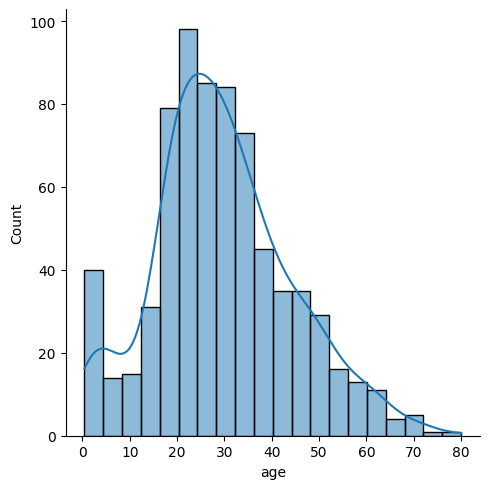

In [ ]:
sns.displot(df['age'], kde = True) #Distribution

In [ ]:
df['mean_age'] = df['age'].fillna(df['age'].mean()) #filling the missing values with the mean of age
df[['mean_age', 'age']]

,mean_age,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


2. __Median Value Imputation__:
- Works best for outliers in data

In [ ]:
df['median_age'] = df['age'].fillna(df['age'].median())
df[['median_age', 'mean_age','age']]

,median_age,mean_age,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


3. Mode Imputation Technique
- Works best for categorical datset

In [ ]:
df[df.embarked.isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,mean_age,median_age
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [ ]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [ ]:
mode_value= df[df['embarked'].notna()]['embarked'].mode()# skip all NaN values

In [ ]:
df['embarked_mode'] = df['embarked'].fillna(mode_value) #filling with the mode value

In [ ]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


### Handling Imbalanced Dataset

Imbalanced dataset = one class appears much more than the other.

Fraud detection:
Non-fraud → 98%
Fraud     → 2%

If you do nothing, the model predicts the majority class and still gets 98% accuracy. That is misleading.

Two basic resampling strategies:

1. __Up sampling__ : Increase the minority class
2. __Down Sampling__ : Reduce the majority class

In [ ]:
import numpy as np
import pandas as pd

#Set the random seed for reproducability - this means everytime we run this we get the same random numbers.
np.random.seed(123)

#Create a dataframe with two classes

n_samples = 1000 # total rows
class_0_ratio = 0.9 # 90% will be class 0
n_class_0 = int(n_samples * class_0_ratio) # 900 class 0 samples
n_class_1 = n_samples - n_class_0 # 100 class 1 samples

In [ ]:
n_class_0,n_class_1

(900, 100)

In [ ]:
#creating a dataset with imbalanced dataset

#class 0 is majority - this creates 900 rows, two features centered at 0 and label = 0.
class_0 = pd.DataFrame({
    'feature_1' : np.random.normal(loc = 0,scale = 1, size = n_class_0),
    'feature_2' : np.random.normal(loc = 0, scale = 1, size = n_class_0),
    'target' : [0] * n_class_0
})

#class 1 is minority - this creates 100 rows, two features centered at 2 and label = 1.
class_1 = pd.DataFrame({
    'feature_1' : np.random.normal(loc = 2,scale = 1, size = n_class_1),
    'feature_2' : np.random.normal(loc = 2, scale = 1, size = n_class_1),
    'target' : [1] * n_class_1
})

In [ ]:
# This will stack class 0 and class 1 vertically and reset row numbers

random_df = pd.concat([class_0,class_1]).reset_index(drop=True)

In [ ]:
random_df.head()

,feature_1,feature_2,target
0,-1.774224,0.285744,0
1,-1.201377,0.333279,0
2,1.096257,0.531807,0
3,0.861037,-0.354766,0
4,-1.520367,-1.120815,0


In [ ]:
random_df.tail()

,feature_1,feature_2,target
995,2.677156,1.092048,1
996,2.963404,0.181955,1
997,1.621476,1.877267,1
998,3.429559,3.794486,1
999,3.532273,1.679490,1


In [ ]:
random_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [ ]:
#Upsampling

#Splitting the dataset by class
df_minority = random_df[random_df['target']==1]
df_majority = random_df[random_df['target']==0]

from sklearn.utils import resample

#sampling from minority class 
df_minority_upsampled = resample(df_minority, replace=True,
         n_samples=len(df_majority),
         random_state=42
         )

df_minority_upsampled.shape

(900, 3)

In [ ]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [ ]:
#Downsampling

df_majority_down = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_downsampled = pd.concat([df_majority_down, df_minority])
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

### Synthetic Minority Oversampling Technique (SMOTE)

SMOTE is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. It involves generating synthetic instances of the minority class by interpolating between existing instances.

Unlike the upsampling and downlampling where we were just copying data points,
- It does not copy points
- It creates new artificial points between existing minority samples


Let's understand with the help of an example:

- A (1,1)
- B (2,2)
- C (1,2)

SMOTE:

- Pick A
- Find its nearest minority neighbors
- Choose one neighbor (say B)
- Create a new point between A and B

Formulae : __new = A + r * (B - A)__ _Where r ∈ (0,1) is random._

Example: 
- A = (1,1)
- B = (3,3)
- r = 0.4

new = (1,1) + 0.4*(2,2)
    = (1.8, 1.8)




In [1]:
#Let's create an imbalanced dataset

from sklearn.datasets import make_classification

#X - independent feature |  y - dependent feature
X,y = make_classification(
    n_samples=1000,
    n_features=2,
    n_clusters_per_class=1,
    weights=[0.9],
    random_state=12,
    n_redundant=0
    )

In [2]:
import pandas as pd
df1 = pd.DataFrame(X, columns = ['f1','f2'])
df2 = pd.DataFrame(y, columns = ['target'])
final_df = pd.concat ([df1,df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [3]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

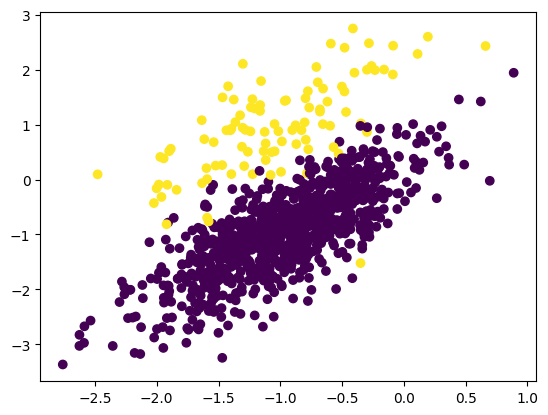

In [4]:
import matplotlib.pyplot as plt

plt.scatter(final_df['f1'], final_df['f2'], c = final_df['target'])

In [6]:
#Applying SMOTE
from imblearn.over_sampling import SMOTE

oversample = SMOTE()
X,y = oversample.fit_resample(final_df[['f1','f2']], final_df['target'])

In [7]:
X.shape

(1800, 2)

In [8]:
y.shape

(1800,)

In [9]:
#How many zeros
len(y[y==0])

900

In [10]:
len(y[y==1])

900

In [11]:
df1 = pd.DataFrame(X, columns = ['f1','f2'])
df2 = pd.DataFrame(y, columns = ['target'])
oversampled_df = pd.concat ([df1,df2], axis=1)

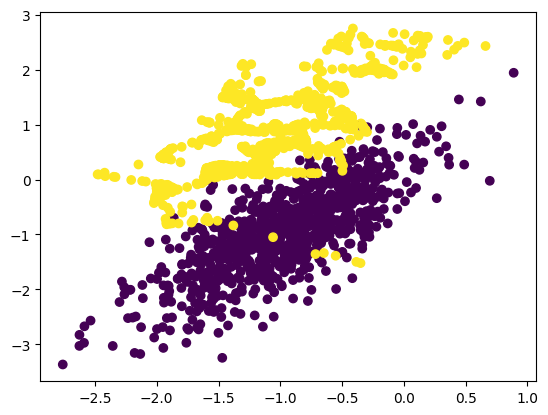

In [12]:
plt.scatter(oversampled_df['f1'], oversampled_df['f2'], c= oversampled_df['target'])

### 5 number summary and boxplot

In [14]:
# 5 number summary - Minimum, Maximum, Median, First Quartile (Q1) and Third Quartile (Q3)

import numpy as np
list_marks = [45,32,54,76,89,43,55,90,98,96,67,39,28,95]
minimum, Q1, median, Q3, maximum = np.quantile(list_marks, [0,0.25,0.5, 0.75,1.0])

In [17]:
minimum, Q1, median, Q3, maximum

(np.float64(28.0),
 np.float64(43.5),
 np.float64(61.0),
 np.float64(89.75),
 np.float64(98.0))

In [18]:
#Interquartile range (IQR)

IQR = Q3-Q1
print(IQR)

46.25


In [ ]:
#Lower fence and higher fence - outlier will be beyond this range

lower_fence = Q1-1.5*IQR
higher_fence = Q3 +1.5*IQR

In [20]:
lower_fence,higher_fence

(np.float64(-25.875), np.float64(159.125))

<Axes: >

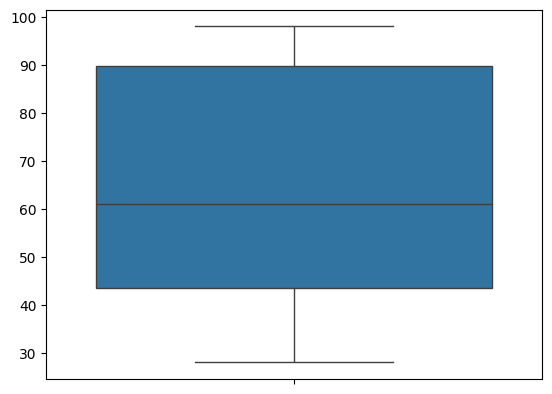

In [ ]:
import seaborn as sns

sns.boxplot(list_marks)

### Data Encoding

1. __Nominal/OHE Encoding__: It is used to represent categorical data as numerical data which is more suitable for machine learning algorithms. In this technique, each category is represneted as a binary vector where each bit corresponds to a unique category. For example, if we have a categorical variable 'color' with three possible values (red, green and blue), we can represent it in one hot encoding as:
- Red [1,0,0]
- Green [0,1,0]
- Blue [0,0,1]


In [22]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [23]:
#creating a data frame

df = pd.DataFrame({'color' : ['red', 'blue', 'green' , 'green', 'red', 'blue']})
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [24]:
#Create an instance of OneHotEncoder

encoder = OneHotEncoder()


In [28]:
#Perform fit and transform
encoded = encoder.fit_transform(df[['color']]).toarray()
encoded

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [30]:
encoder_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [31]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


2. __Label Encoding__: It is used assign a unique numerical label to each category in the variable. The labels are usually assigned in aplhabetical order or based on the frequency of the categories. For example, if we have a categorical variable 'color' with three possible values (red, green and blue), we can represent it in one hot encoding as:
 - Red : 1
 - Green : 2
 - Blue : 3


In [46]:
# Import LabelEncoder from Sklearn

from sklearn.preprocessing import LabelEncoder

#creating a data frame

df = pd.DataFrame({'color' : ['red', 'blue', 'green' , 'green', 'red', 'blue']})
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [47]:
#Initialize the encoder

lbl_encoder = LabelEncoder()

In [48]:
lbl_encoder.fit_transform(df[['color']])

d:\Learning\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [49]:
lbl_encoder.transform([['red']])

d:\Learning\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [50]:
lbl_encoder.transform([['blue']])

d:\Learning\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

3. __Ordinal Encoding__: It is used to encode categorical data that has an intrinsic order or ranking. In this technique, each category is assigned a numerical value based on its position in the order. For example, if we have a categorical variable called "education level" with four possible values (high school, college, graduate, post-graduate), we can represent it using ordinal encoding as follows:
- High School : 1
- College : 2
- Graduate : 3
- Post-Graduate : 4

In [51]:
#Import OrdinalEncoder

from sklearn.preprocessing import OrdinalEncoder

#Dataframe
df = pd.DataFrame({'size' : ['small', 'medium', 'large', 'medium', 'small', 'large']})
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [52]:
#create an instance and fit_transform

encoder = OrdinalEncoder(categories=[['small', 'medium', 'large']])

In [53]:
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])

4. __Target Guided Ordinal Encoding__: Used to encode categorical variable based on the relationship with the target variable. This encoding technique is useful when we have a categorical variable with a large number of unique categories and we want to use this variable as feature in our ML model.In this, we replace category in the categorical variable with a numercial value based on the mean or median of the target variable for that category. This creates a monotonic relationship between categorical variable and target variable which can improve the predictive power of the model.

In [55]:
import pandas as pd

#Create a sample dataframe with a categorical variable and a target variable

df = pd.DataFrame({
    'city' : ['New York', 'London', 'Paris', 'Tokyo', 'New York', 'Paris'],
    'price' : [200,150,300,250,180,320]
})

df

,city,price
0,New York,200
1,London,150
2,Paris,300
3,Tokyo,250
4,New York,180
5,Paris,320


In [ ]:
df.groupby('city')['price'].mean()

city
London      150.0
New York    190.0
Paris       310.0
Tokyo       250.0
Name: price, dtype: float64

In [58]:
mean_price = df.groupby('city')['price'].mean().to_dict()
mean_price

{'London': 150.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}

In [59]:
df['city_encoded'] = df['city']. map(mean_price)
df

,city,price,city_encoded
0,New York,200,190.0
1,London,150,150.0
2,Paris,300,310.0
3,Tokyo,250,250.0
4,New York,180,190.0
5,Paris,320,310.0


In [60]:
import seaborn as sns

df_tips = sns.load_dataset('tips')
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [61]:
#Let's convert time based on total_bill

df_tips.groupby('time')['total_bill'].mean()

time
Lunch     17.168676
Dinner    20.797159
Name: total_bill, dtype: float64

In [64]:
mean_bill = df_tips.groupby('time')['total_bill'].mean().to_dict()
mean_bill

{'Lunch': 17.168676470588235, 'Dinner': 20.79715909090909}

In [65]:
df_tips['time_encoded'] = df_tips['time'].map(mean_bill)
df_tips

,total_bill,tip,sex,smoker,day,time,size,time_encoded
0,16.99,1.01,Female,No,Sun,Dinner,2,20.797159
1,10.34,1.66,Male,No,Sun,Dinner,3,20.797159
2,21.01,3.50,Male,No,Sun,Dinner,3,20.797159
3,23.68,3.31,Male,No,Sun,Dinner,2,20.797159
4,24.59,3.61,Female,No,Sun,Dinner,4,20.797159
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.797159
240,27.18,2.00,Female,Yes,Sat,Dinner,2,20.797159
241,22.67,2.00,Male,Yes,Sat,Dinner,2,20.797159
242,17.82,1.75,Male,No,Sat,Dinner,2,20.797159
